# Lecture 8 – Data 100, Spring 2026

[Acknowledgments Page](https://ds100.org/sp26/acks/)

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(context='notebook', style='whitegrid', palette='colorblind')

In [2]:
wb = pl.read_csv("data/world_bank.csv").drop("")
wb = wb.rename({
    'Antiretroviral therapy coverage: % of people living with HIV: 2015': "HIV rate",
    'Gross national income per capita, Atlas method: $: 2016': 'gni'
})
# This can be a helpful way to refer to a very long column name:
MATH_PISA_COL = "Students at lowest proficiency on PISA: Mathematics: % of 15 year-olds: 2015"
wb.head()

Continent,Country,Primary completion rate: Male: % of relevant age group: 2015,Primary completion rate: Female: % of relevant age group: 2015,Lower secondary completion rate: Male: % of relevant age group: 2015,Lower secondary completion rate: Female: % of relevant age group: 2015,Youth literacy rate: Male: % of ages 15-24: 2005-14,Youth literacy rate: Female: % of ages 15-24: 2005-14,Adult literacy rate: Male: % ages 15 and older: 2005-14,Adult literacy rate: Female: % ages 15 and older: 2005-14,Students at lowest proficiency on PISA: Mathematics: % of 15 year-olds: 2015,Students at lowest proficiency on PISA: Reading: % of 15 year-olds: 2015,Students at lowest proficiency on PISA: Science: % of 15 year-olds: 2015,Population: millions: 2016,Surface area: sq. km thousands: 2016,Population density: people per sq. km: 2016,"Gross national income, Atlas method: $ billions: 2016",gni,Purchasing power parity gross national income: $ billions: 2016,per capita: $: 2016,Gross domestic product: % growth : 2016,per capita: % growth: 2016,Prevalence of smoking: Male: % of adults: 2015,Prevalence of smoking: Female: % of adults: 2015,"Incidence of tuberculosis: per 100,000 people: 2015",Prevalence of diabetes: % of population ages 20 to 79: 2015,Incidence of HIV: Total: % of uninfected population ages 15-49: 2015,Prevalence of HIV: Total: % of population ages 15-49: 2015,Prevalence of HIV: Women's share of population ages 15+ living with HIV: %: 2015,"Prevalence of HIV: Youth, Male: % of population ages 15-24: 2015","Prevalence of HIV: Youth, Female: % of population ages 15-24: 2015",HIV rate,"Cause of death: Communicable diseases and maternal, prenatal, and nutrition conditions: % of population: 2015",Cause of death: Non-communicable diseases: % of population: 2015,Cause of death: Injuries: % of population: 2015,Access to an improved water source: % of population: 1990,Access to an improved water source: % of population: 2015,Access to improved sanitation facilities: % of population: 1990,Access to improved sanitation facilities: % of population: 2015,Child immunization rate: Measles: % of children ages 12-23 months: 2015,Child immunization rate: DTP3: % of children ages 12-23 months: 2015,Children with acute respiratory infection taken to health provider: % of children under age 5 with ARI: 2009-2016,Children with diarrhea who received oral rehydration and continuous feeding: % of children under age 5 with diarrhea: 2009-2016,Children sleeping under treated bed nets: % of children under age 5: 2009-2016,Children with fever receiving antimalarial drugs: % of children under age 5 with fever: 2009-2016,Tuberculosis: Treatment success rate: % of new cases: 2014,Tuberculosis: Cases detection rate: % of new estimated cases: 2015
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Africa""","""Algeria""",106.0,105.0,68.0,85.0,96.0,92.0,83.0,68.0,51.0,11.0,4.0,40.6,2381.7,17.0,173.5,4270.0,597.9,14720.0,3.7,1.8,null,null,75.0,7.5,0.01,0.1,46.0,0.1,0.1,90.0,16.0,74.0,10.0,92.0,84.0,80.0,88.0,95.0,95.0,66.0,42.0,null,null,88.0,80.0
"""Africa""","""Angola""",null,null,null,null,79.0,67.0,82.0,60.0,null,null,null,28.8,1246.7,23.0,99.0,3440.0,179.3,6220.0,0.0,-3.3,null,null,370.0,4.1,0.19,2.2,60.0,0.5,0.9,29.0,62.0,27.0,11.0,46.0,49.0,22.0,52.0,55.0,64.0,null,null,25.9,28.3,34.0,64.0
"""Africa""","""Benin""",83.0,73.0,50.0,37.0,55.0,31.0,41.0,18.0,null,null,null,10.9,114.8,96.0,8.9,820.0,23.6,2170.0,4.0,1.1,18.0,1.0,60.0,0.8,0.07,1.1,58.0,0.2,0.4,49.0,52.0,37.0,10.0,57.0,78.0,7.0,20.0,75.0,79.0,23.0,33.0,72.7,25.9,89.0,61.0
"""Africa""","""Botswana""",98.0,101.0,86.0,87.0,96.0,99.0,87.0,89.0,null,null,null,2.3,581.7,4.0,14.9,6610.0,36.9,16380.0,2.9,1.0,null,null,356.0,5.6,0.94,22.2,57.0,3.9,9.8,78.0,49.0,42.0,9.0,92.0,96.0,39.0,63.0,97.0,95.0,null,null,null,null,77.0,62.0
"""Africa""","""Burundi""",58.0,66.0,35.0

## Scatter Plots

Scatter plots are used to visualize the **relationship** between two **quantitative continuous variables**.

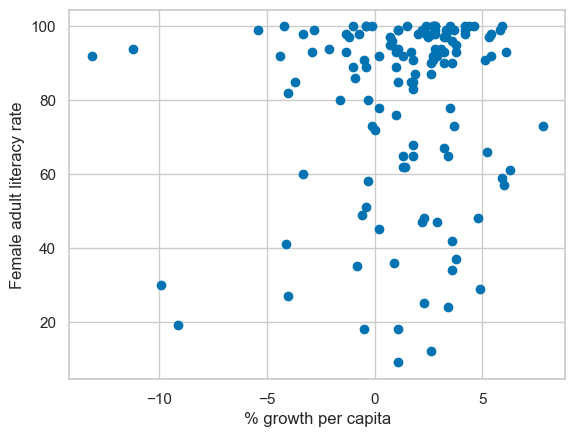

In [3]:
plt.scatter(wb['per capita: % growth: 2016'],
            wb['Adult literacy rate: Female: % ages 15 and older: 2005-14'])
plt.xlabel("% growth per capita")
plt.ylabel("Female adult literacy rate");

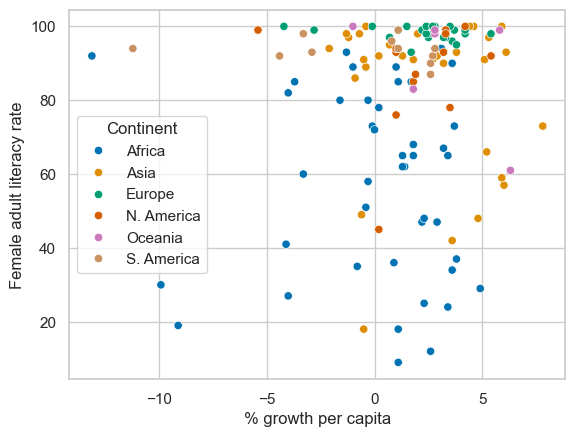

In [4]:
sns.scatterplot(data=wb.to_pandas(), x='per capita: % growth: 2016', \
                y='Adult literacy rate: Female: % ages 15 and older: 2005-14', hue="Continent")
plt.xlabel("% growth per capita")
plt.ylabel("Female adult literacy rate");

The plots above suffer from **overplotting** – many scatter points are stacked on top of one another (particularly in the upper right region of the plot). 

Methods to address: Reduce point size (`size`), increase transparency (`alpha`), or jitter.

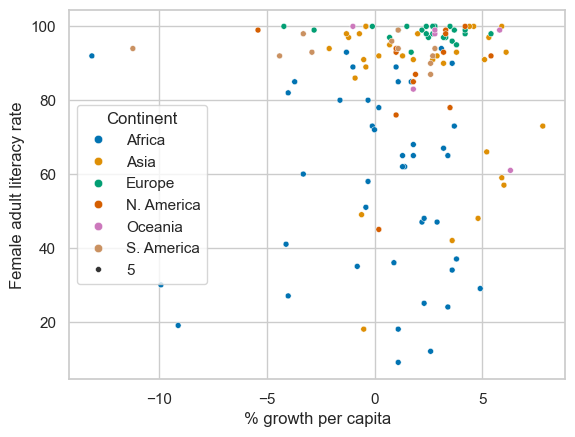

In [5]:
sns.scatterplot(data=wb.to_pandas(), x='per capita: % growth: 2016', \
                y='Adult literacy rate: Female: % ages 15 and older: 2005-14', hue="Continent", 
                size=5)
plt.xlabel("% growth per capita")
plt.ylabel("Female adult literacy rate");

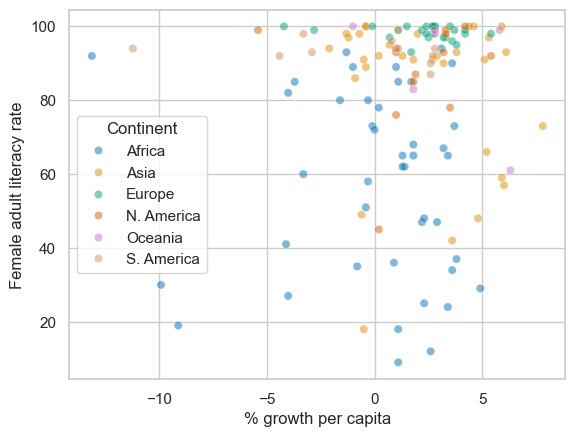

In [9]:
sns.scatterplot(data=wb, x='per capita: % growth: 2016', \
                y='Adult literacy rate: Female: % ages 15 and older: 2005-14', hue="Continent", 
                alpha=0.5)
plt.xlabel("% growth per capita")
plt.ylabel("Female adult literacy rate");

**Jittering** can address overplotting. A small amount of random noise is added to the x and y values of all datapoints. 

Decreasing the size of each scatter point using the `s` parameter of `plt.scatter` also helps.

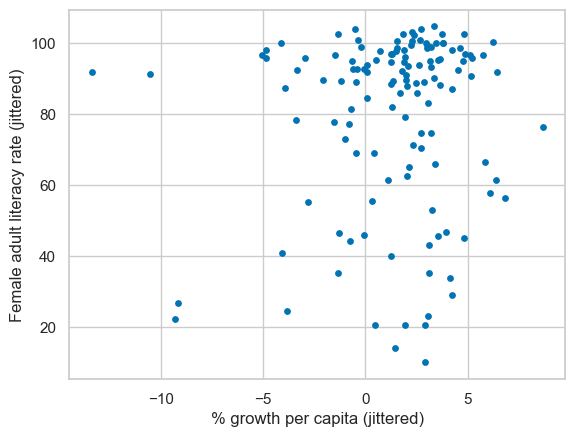

In [10]:
random_x_noise = np.random.uniform(-1, 1, len(wb))
random_y_noise = np.random.uniform(-5, 5, len(wb))

plt.scatter(wb['per capita: % growth: 2016']+random_x_noise, 
            wb['Adult literacy rate: Female: % ages 15 and older: 2005-14']+random_y_noise, s=15)

plt.xlabel("% growth per capita (jittered)")
plt.ylabel("Female adult literacy rate (jittered)");

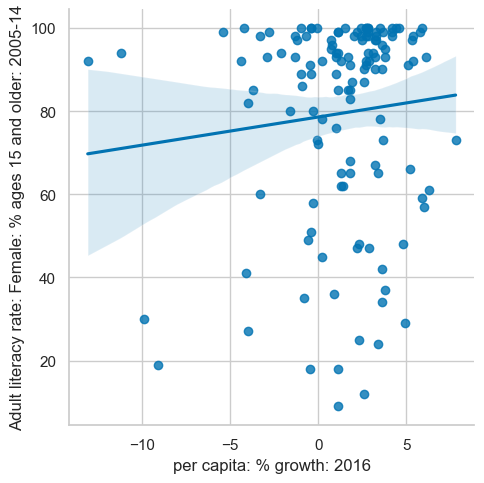

In [14]:
sns.lmplot(data=wb, x='per capita: % growth: 2016',
           y='Adult literacy rate: Female: % ages 15 and older: 2005-14');

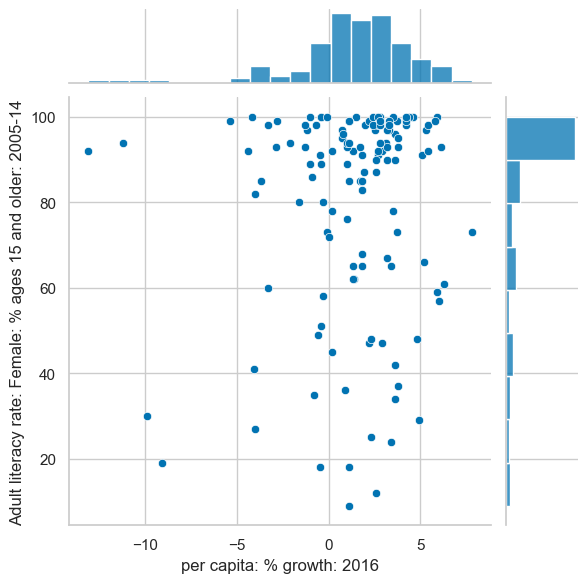

In [16]:
sns.jointplot(data=wb, x='per capita: % growth: 2016', 
              y='Adult literacy rate: Female: % ages 15 and older: 2005-14');

## Hex Plots

Rather than plot individual datapoints, plot the *density* of how datapoints are distributed in 2D. A darker hexagon means that more datapoints lie in that region.

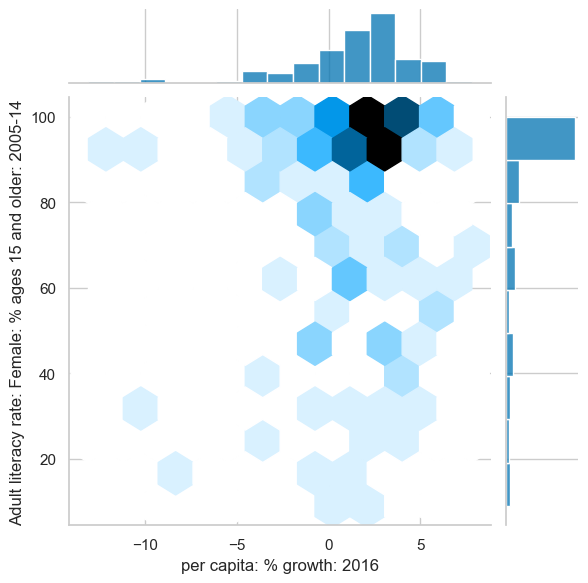

In [18]:
sns.jointplot(data=wb, x='per capita: % growth: 2016', 
              y='Adult literacy rate: Female: % ages 15 and older: 2005-14',
              kind='hex');

## Contour Plots

Contour plots are similar to topographic maps. Contour lines of the same color have the same *density* of datapoints. The region with the darkest color contains the most datapoints of all regions.

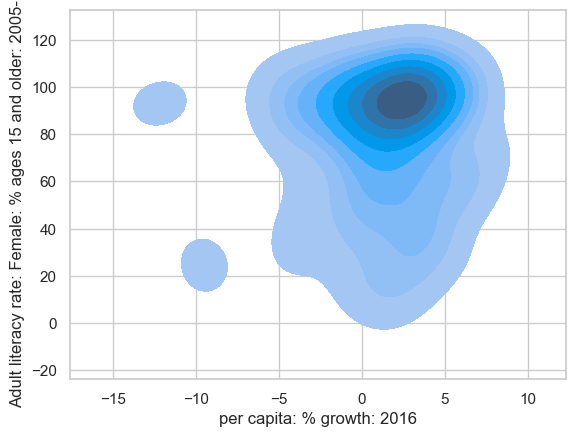

In [23]:
sns.kdeplot(data=wb, x='per capita: % growth: 2016', 
              y='Adult literacy rate: Female: % ages 15 and older: 2005-14', fill=True);

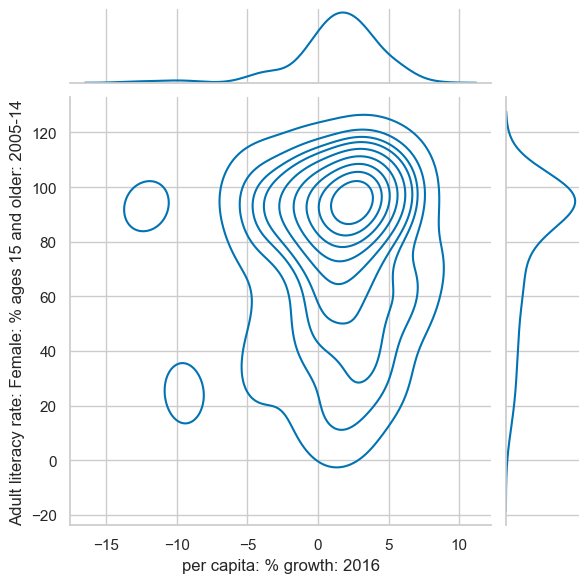

In [24]:
sns.jointplot(data=wb, x='per capita: % growth: 2016', 
              y='Adult literacy rate: Female: % ages 15 and older: 2005-14',
              kind='kde');

## Transformations

Often, our reason for visualizing relationships like we did above is because we then want to *model* these relationships. We will start talking about the theory and math underlying modeling processes next week.

We will focus a lot on **linear modeling** in Data 100. This means that it is often helpful to transform and **linearize** our data such that it shows roughly a linear relationship. There are a few reasons for this:
* Transforming data makes visualizations easier to interpret
* Linear relationships are straightforward to understand – we have ideas of what slopes and intercepts mean
* Later on in the course, the ability to linearize data will help us make more effective models

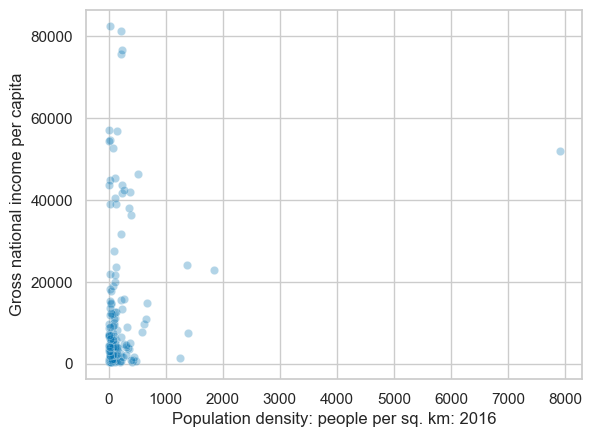

In [26]:
sns.scatterplot(wb, x="Population density: people per sq. km: 2016", y="gni", alpha=0.3);
plt.ylabel("Gross national income per capita");

What is making this plot non-linear?

Both x and y variables have a few large values that are distorting the scale of the plot. We can see that most of the "action" is happening within the lower left box of the grid. If we rescaled the x-values and y-values such that these large values become proportionally smaller, the plot would be more linear!

First, we can transform the y-values such that very large values of y become smaller. This can be achieved by performing a **log transformation** of the gross national income data. When we take the logarithm of a large number, this number becomes proportionally much smaller relative to its original value. When we take the log of a small number, the number does not change very significantly relative to its starting value.

There are two ways we can do this:
1. By transforming the data and plotting the transformed variable
2. By telling matplotlib to modify the plot so that gross national income is on a log scale.

In order to do (1), we'll switch from the seaborn plotting function to matplotlib's `scatter`. If we wanted to do this in seaborn, we'd need to add a new column with the log-transformed data.

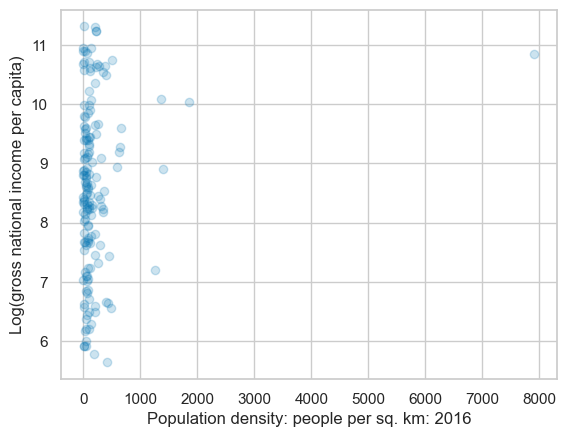

In [27]:
# np.log computes the natural (base e) logarithm
plt.scatter(wb["Population density: people per sq. km: 2016"], np.log(wb["gni"].to_numpy()), alpha=0.2)
plt.xlabel("Population density: people per sq. km: 2016")
plt.ylabel("Log(gross national income per capita)");

This has done a good job stretching out the y-values, but the x-values are still squished! Let's do the same thing for the x-values next:

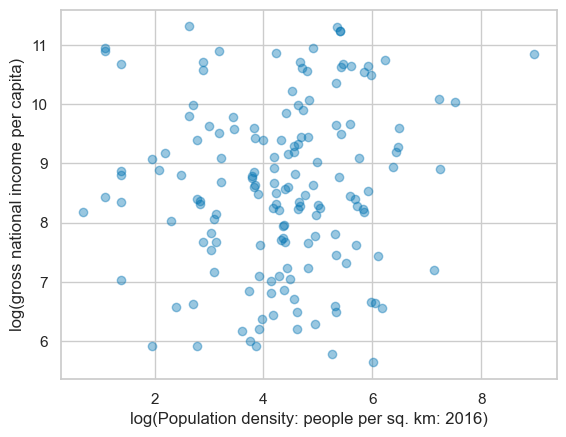

In [28]:
# np.log computes the natural (base e) logarithm
plt.scatter(np.log(wb["Population density: people per sq. km: 2016"].to_numpy()), np.log(wb["gni"].to_numpy()), alpha=0.4)
plt.xlabel("log(Population density: people per sq. km: 2016)")
plt.ylabel("log(gross national income per capita)");

Now, we can clearly see the relationship between these variables: namely, that they look mostly uncorrelated!

We could also have done the same thing by using the `plt.semilogx()`, `plt.semilogy()`, and `plt.loglog()` functions, which modify the plot so that the x-axis, y-axis, or both are shown on a log scale.

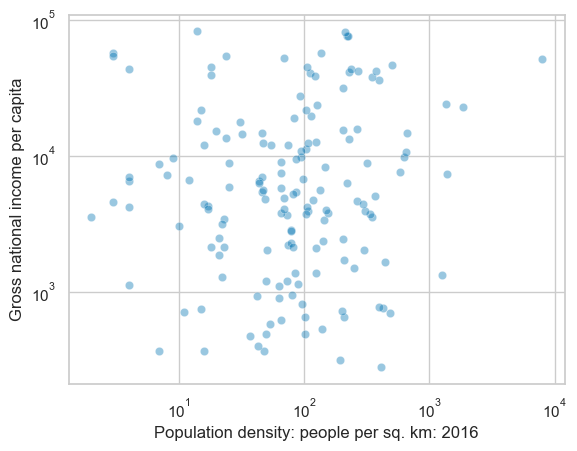

In [30]:
sns.scatterplot(wb, x="Population density: people per sq. km: 2016", y="gni", alpha=0.4);
plt.ylabel("Gross national income per capita")
# Changes the plot so that x and y are shown on a log scale
plt.loglog();

Notice that the points look the same as before, but now the axis labels are shown in their original scale.

Let's look at another example:

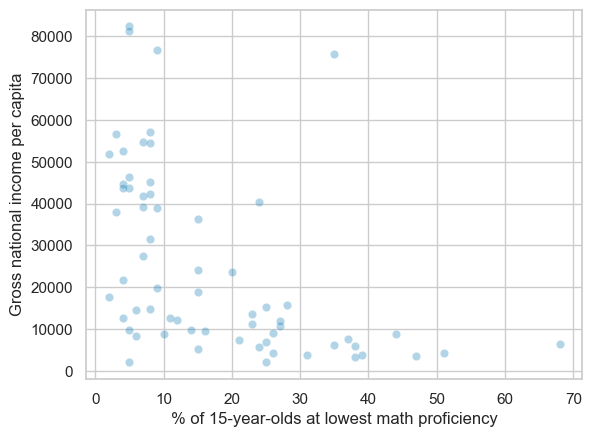

In [32]:
# The column name is long and annoying to type, so we defined a variable with it at the top of our notebook.
sns.scatterplot(wb, x=MATH_PISA_COL, y="gni", alpha=0.3);
plt.xlabel("% of 15-year-olds at lowest math proficiency")
plt.ylabel("Gross national income per capita");

We can see some skew in the new x-variable, but let's start by log-transforming the gross national income data again:

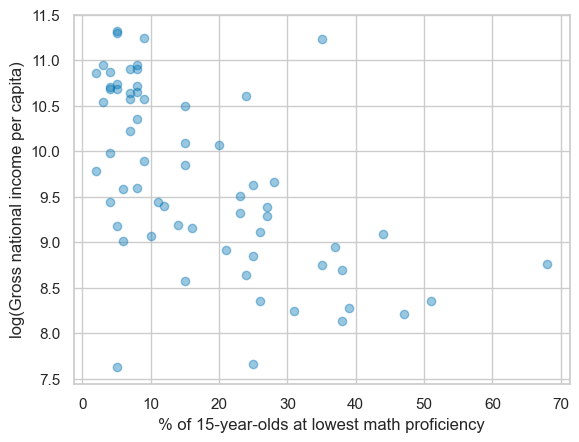

In [33]:
plt.scatter(wb[MATH_PISA_COL], np.log(wb["gni"].to_numpy()), alpha=0.4)
plt.xlabel("% of 15-year-olds at lowest math proficiency")
plt.ylabel("log(Gross national income per capita)");

We can see that we have a mostly linear relationship! We can express this mathematically:

$$\log(y) = mx + b$$

We can use this fact to uncover new information about the original, untransformed variables. 

$$y = e^{mx + b} = e^{mx}e^b $$

In the cell below, we first fit a regression line to the transformed data to find values for the slope ($m$) and intercept ($b$). Then, we plug these values into the relationship we derived for the *untransformed* variables. We find a mathematical relationship relating the gross national income and the adult literacy rate.

The slope, m, of the transformed data is: -0.0408098136500104
The intercept, b, of the transformed data is: 10.416008267765228


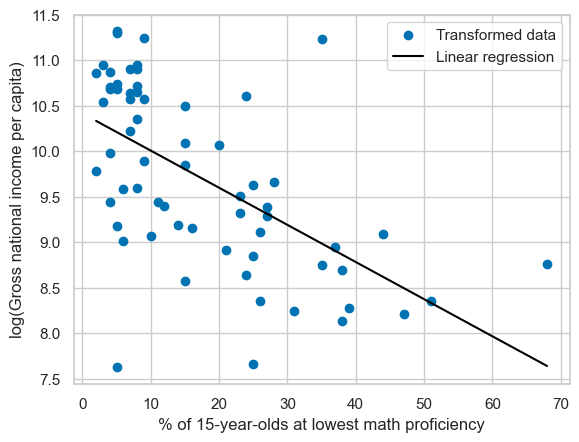

In [34]:
# The code below fits a linear regression model. We'll discuss it at length in a future lecture.
from sklearn.linear_model import LinearRegression


# We're dropping rows with missing data: this might not be a good idea! Why not?
wb_trimmed = wb.drop_nulls(subset=[MATH_PISA_COL, "gni"])

model = LinearRegression()
model.fit(wb_trimmed[[MATH_PISA_COL]], np.log(wb_trimmed["gni"].to_numpy()))
m, b = model.coef_[0], model.intercept_

print(f"The slope, m, of the transformed data is: {m}")
print(f"The intercept, b, of the transformed data is: {b}")

# Now, we want to plot multiple things on the same plot: this is a good time to switch to matplotlib!
df = wb.sort(MATH_PISA_COL)
pisa = df[MATH_PISA_COL]
plt.scatter(pisa, np.log(df["gni"].to_numpy()), label="Transformed data")
plt.plot(pisa, m*pisa+b, c="black", label="Linear regression")
plt.xlabel("% of 15-year-olds at lowest math proficiency")
plt.ylabel("log(Gross national income per capita)");
plt.legend();

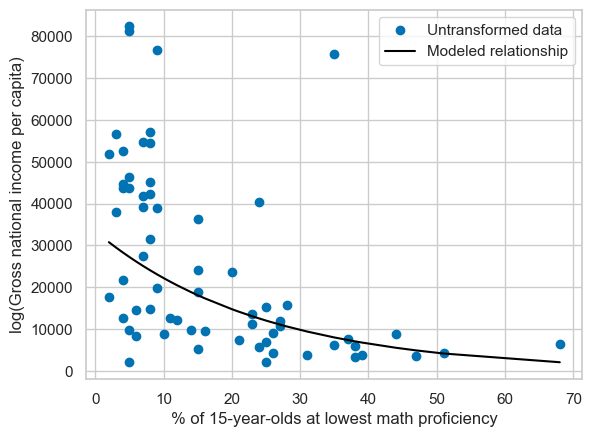

In [35]:
# Now, plug the values for m and b into the relationship between the untransformed x and y

plt.scatter(pisa, df["gni"], label="Untransformed data")
plt.plot(pisa, np.exp(m*pisa+b), c="black", label="Modeled relationship")
plt.xlabel("% of 15-year-olds at lowest math proficiency")
plt.ylabel("log(Gross national income per capita)");
plt.legend();

We've been able to find a fairly close approximation for the relationship between the original variables!

### Conditioning

In [36]:
# The file ends with a blank line, which reads in as a row of nulls.
cps = pl.read_csv("data/edInc2.csv").drop_nulls()
cps

educ,gender,income
i64,str,i64
1,"""Men""",517
1,"""Women""",409
2,"""Men""",751
2,"""Women""",578
3,"""Men""",872
3,"""Women""",661
4,"""Men""",1249
4,"""Women""",965
5,"""Men""",1385


In [37]:
cps = cps.with_columns(pl.col("educ").replace_strict({1:"<HS", 2:"HS", 3:"<BA", 4:"BA", 5:">BA"}))
cps.columns = ['Education', 'Gender', 'Income']
cps

Education,Gender,Income
str,str,i64
"""<HS""","""Men""",517
"""<HS""","""Women""",409
"""HS""","""Men""",751
"""HS""","""Women""",578
"""<BA""","""Men""",872
"""<BA""","""Women""",661
"""BA""","""Men""",1249
"""BA""","""Women""",965
""">BA""","""Men""",1385


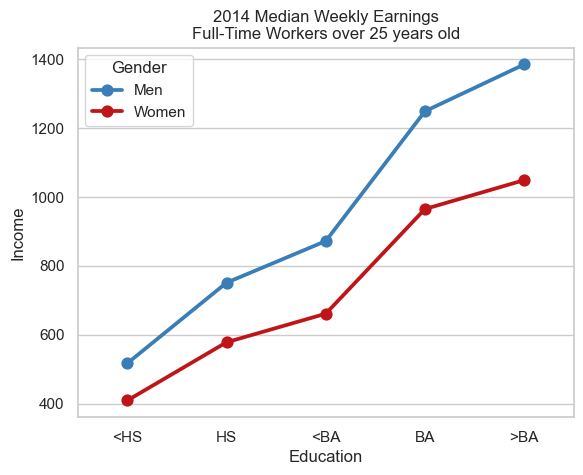

In [39]:
# Let's pick our colors specifically using color_palette()
blue_red = ["#397eb7", "#bf1518"]
with sns.color_palette(sns.color_palette(blue_red)):
    ax = sns.pointplot(data=cps, x="Education", y="Income", hue="Gender")

ax.set_title("2014 Median Weekly Earnings\nFull-Time Workers over 25 years old");

Now, let's compute the income gap as a relative quantity between men and women. Recall that the structure of the dataframe is as follows:

In [40]:
cps.head()

Education,Gender,Income
str,str,i64
"""<HS""","""Men""",517
"""<HS""","""Women""",409
"""HS""","""Men""",751
"""HS""","""Women""",578
"""<BA""","""Men""",872


Splitting the table by Gender gives us one sub-table per group, which we can then divide to get the ratio:

In [41]:
cg = cps.partition_by("Gender", as_dict=True, include_key=False)
men = cg[("Men",)]
women = cg[("Women",)]
display(men, women)

Education,Income
str,i64
"""<HS""",517
"""HS""",751
"""<BA""",872
"""BA""",1249
""">BA""",1385


Education,Income
str,i64
"""<HS""",409
"""HS""",578
"""<BA""",661
"""BA""",965
""">BA""",1049


In [42]:
mfratio = men.select("Education", men["Income"] / women["Income"])
mfratio.columns = ["Education", "Income Ratio (M/F)"]
mfratio

Education,Income Ratio (M/F)
str,f64
"""<HS""",1.264059
"""HS""",1.299308
"""<BA""",1.319213
"""BA""",1.294301
""">BA""",1.320305


In [ ]:
ax = sns.lineplot(data=mfratio.to_pandas(), x="Education", y="Income Ratio (M/F)",
                  markers=True, legend=False);
ax.set_ylabel("Ratio")
ax.set_title("M/F Income Ratio as a function of education level");

Let's now compute the alternate ratio, F/M instead:

In [ ]:
fmratio = women.select("Education", women["Income"] / men["Income"])
fmratio.columns = ["Education", "Income Ratio (F/M)"]
fmratio

In [ ]:
ax = sns.lineplot(data=fmratio.to_pandas(), x="Education", y="Income Ratio (F/M)",
                  markers=True, legend=False);
ax.set_ylabel("Ratio")
ax.set_title("F/M Income Ratio as a function of education level");

### Baseline consideration

In [ ]:
co2 = pl.read_csv("data/CAITcountryCO2.csv", skip_rows=2, has_header=False,
                  new_columns=["Country", "Year", "CO2"], encoding="latin-1")
co2.tail()

In [ ]:
last_year = co2["Year"][-1]
last_year

In [ ]:
top14_lasty = co2.filter(
    ~pl.col("Country").is_in(["World", "European Union (15)"]),
    pl.col("Year") == last_year
).sort("CO2", descending=True, nulls_last=True).head(14)
top14_lasty

In [ ]:
top14 = co2.filter(
    pl.col("Country").is_in(top14_lasty["Country"].to_list()),
    pl.col("Year") >= 1950
)
print(top14["Country"].n_unique())
top14.head()

In [ ]:
from cycler import cycler

linestyles = ['-', '--', ':', '-.' ]
colors = plt.cm.Dark2.colors
lines_c = cycler('linestyle', linestyles)
color_c = cycler('color', colors)

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_prop_cycle(color_c * lines_c)

x, y ='Year', 'CO2'
for (name,), df in top14.group_by('Country', maintain_order=True):
    ax.semilogy(df[x], df[y], label=name)

ax.set_xlabel(x)
ax.set_ylabel(f"{y} Emissions (million tons)")
ax.legend(ncol=2, frameon=True, fontsize=11);

## Slido exercise

In [ ]:
example = pl.DataFrame({
    'cost': [3.0, 4.0, 3.1],
    'version': ['3.1', '4', '4',],
    'weight': [3.0, 3.1, 4.0],
    'rating': [4, 3, 4]
})
example

In [ ]:
plt.figure(figsize=(3, 3))
sns.scatterplot(example.to_pandas(), x='cost', y='weight', hue='version', size='rating')

In [ ]:
distractor = pl.DataFrame({
    'rating': [3.0, 4.0, 3.1],
    'cost': ['3.1', '4.0', '4.0',],
    'weight': [3.0, 3.1, 4.0],
    'version': [4, 3, 4]
})
distractor